**Assignment Overview**

In this assignment, you will explore two fundamental aspects of modern NLP systems: fine-tuning large language models and understanding the attention mechanism that powers them.

**Learning Goals**

By the end of this assignment, you should be able to:

* Understand when and why to fine-tune language models
* Apply QLoRA for efficient adaptation of large models
* Analyze model outputs and limitations
* Explain and implement the attention mechanism
* Interpret attention patterns and their behavior

**Important Note**

* Do not modify or delete the task structure.
* Complete each task with:
   - Clean, well-organized code
   - Relevant visualizations
   - Clear insights and explanations
* Make sure to answer all required questions.
**Submission requirements:**
* Submit a **fully executed notebook** (all cells must run and outputs should be visible).
* There is no need to attach the training and test datasets as files, but you must present them as DataFrame tables within the notebook.


## Install Required Packages and Dataset

In [ ]:
# %pip install transformers peft trl bitsandbytes
# %pip install dotenv openai

  Using cached openai-2.36.0-py3-none-any.whl (1.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.8/361.8 kB 1.9 MB/s eta 0:00:001.7 MB/s eta 0:00:01
  Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
  Using cached distro-1.9.0-py3-none-any.whl (20 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
  Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: /home/labs/antebilab/guyilan/Courses/Nebius/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSeq2SeqLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
    pipeline,
    logging,
    DataCollatorForLanguageModeling,
    Trainer
)
from peft import LoraConfig, TaskType, prepare_model_for_kbit_training, get_peft_model,PeftModel
from trl import SFTTrainer
import torch
import json
from datasets import Dataset, load_dataset
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')
logging.set_verbosity(logging.CRITICAL)
load_dotenv()

/home/labs/antebilab/guyilan/Courses/Nebius/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_2672473/2265807760.py:19: FutureWarning: Support for Python 3.9 will be dropped in the next release (after its end-of-life on October 31, 2025). Please upgrade to Python 3.10 or newer.
  from trl import SFTTrainer


True

 ## **Part 1 — QLoRA Fine-Tuning for Level-Adaptive Question Answering (75 points)** 

In this part, you will fine-tune pretrained language models to answer questions at different explanation levels:

* Child — simple and intuitive explanation
* Student — clear educational explanation with moderate technical detail
* Expert — precise, technical, and domain-specific explanation

You will use a subset of the Databricks Dolly 15K dataset. 

In [2]:
dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:5000]")


In [3]:
def is_good_question(text):
    return any(q in text.lower() for q in [
        "why", "how", "what is", "explain"
    ])

filtered = [
    ex for ex in dataset
    if ex["category"] == "open_qa" and is_good_question(ex["instruction"])
]

In [ ]:
len(filtered), filtered[0]

(580,
 {'instruction': 'Why can camels survive for long without water?',
  'context': '',
  'response': 'Camels use the fat in their humps to keep them filled with energy and hydration for long periods of time.',
  'category': 'open_qa'})

### **Task 1.1 — Prepare a Custom Dataset (15 points)**

 Create your own instruction-tuning dataset based on a subset of databricks-dolly-15k.

For each selected question-answer pair, create versions of the answer adapted to the requested expertise level.

Example format:

    Question: What is gradient descent?
    Expertise level: child
    Answer: Gradient descent is like walking downhill step by step until you reach the lowest point.

You should prepare:

1. Training set for fine-tuning -

   Use the filtered Dolly dataset as your source of questions.

   For each question, create examples in the example format per level.

2. Test set for evaluation -
    
   Create a small test set of 20 question-answer examples.

   The test set must:

  * include examples from all three expertise levels
  * be separate from the training set
  * be manually reviewed by you for quality
  * include answers that are appropriate for the requested expertise level

  Recommendation:

  1. Save the generated dataset as a '.jsonl' file so it can be loaded and reused later.

  2. Decide on the training format according to the model architecture:
    
    - For causal language models, such as `HuggingFaceTB/SmolLM2-360M-Instruct`, use one full text field:

    ```text
    ### Question:
    ...

    ### Expertise level:
    child / student / expert

    ### Answer:
    ...```

    - For seq2seq models, such as google/flan-t5-small, separate the input and target:

    input: Question + expertise level
    target: Answer
   
  3. Before generating the full dataset, test the pipeline on a small batch of examples to verify that:

  * the LLM returns valid JSON,
  * each question receives three expertise-level answers,
  * the saved .jsonl file can be loaded correctly,
  * the format matches the training code. -->

In [5]:
NEBIUS_BASE_URL = "https://api.tokenfactory.nebius.com/v1/"
MODEL = "meta-llama/Meta-Llama-3.1-8B-Instruct"

client = OpenAI(
    base_url=NEBIUS_BASE_URL,
    api_key=os.getenv("NEBIUS_API_KEY"),
)

In [6]:
def generate_level_answers(question: str, max_retries: int = 2) -> dict:
    system_prompt = (
        "You are an expert teacher who adapts explanations to different expertise levels.\n"
        "For the given question, write three answers: one for a child, one for a student, one for an expert.\n"
        "Return ONLY a valid JSON object with exactly these string fields: "
        "child, student, expert. No extra commentary."
    )

    user_prompt = f"Question: {question}"

    last_error = None

    for attempt in range(max_retries):
        resp = client.chat.completions.create(
            model="meta-llama/Meta-Llama-3.1-8B-Instruct",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=0.7,
        )

        content = resp.choices[0].message.content

        # First try: direct JSON
        try:
            data = json.loads(content)
        except json.JSONDecodeError:
            # Second try: extract between first { and last }
            start = content.find("{")
            end = content.rfind("}")
            if start == -1 or end == -1:
                last_error = f"Non-JSON output (no braces): {content}"
                continue

            json_str = content[start : end + 1]
            try:
                data = json.loads(json_str)
            except json.JSONDecodeError as e:
                last_error = f"JSONDecodeError after brace-extraction: {e}\nRAW: {content}"
                continue

        # Sanity check keys
        if not all(k in data for k in ["child", "student", "expert"]):
            last_error = f"Missing keys in parsed JSON: {data}"
            continue

        return data  # success

    # If we get here, all attempts failed
    raise ValueError(f"Failed to get valid JSON for question: {question}\nLast error: {last_error}")

In [7]:
train_base = filtered[:500]
test_base = filtered[500:520]

len(train_base), len(test_base)

(500, 20)

### Generate the dataset using an LLM

In [ ]:
train_records = []

for i, ex in enumerate(tqdm(train_base, desc="Generating train set")):
    q = ex["instruction"]

    try:
        answers = generate_level_answers(q)
    except ValueError as e:
        print(f"\n[WARN] Skipping question index {i} due to parse error:\n{e}\n")
        continue

    base_id = f"train_{i}"

    for level in ["child", "student", "expert"]:
        train_records.append({
            "id": base_id,
            "question": q,
            "expertise_level": level,
            "answer": answers[level],
        })

In [ ]:
with open("train_level_qa.jsonl", "w", encoding="utf-8") as f:
    for rec in train_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

In [8]:
train_loaded = [json.loads(l) for l in open("train_level_qa.jsonl", encoding="utf-8")]
len(train_loaded), train_loaded[0]

(1488,
 {'id': 'train_0',
  'question': 'Why can camels survive for long without water?',
  'expertise_level': 'child',
  'answer': "Camels have special bodies that help them keep water inside. Their kidneys are super good at making sure that every drop of water is used up. They can go a long time without drinking because they have a special way to reuse water from their pee and poop. It's like a special water-saving system!"})

In [9]:
test_base = filtered[500:520]  # 20 distinct questions
len(test_base)  # should be 20

20

#### Generate the dataset using an LLM (test)

In [ ]:
test_records = []

for i, ex in enumerate(test_base):
    q = ex["instruction"]
    try:
        answers = generate_level_answers(q)
    except Exception as e:
        print(f"\n[WARN] Skipping test question index {i} due to parse error:\n{e}\n")
        continue

    base_id = f"test_{i}"

    for level in ["child", "student", "expert"]:
        test_records.append({
            "id": base_id,
            "question": q,
            "expertise_level": level,
            "answer": answers[level],
        })

In [ ]:
with open("test_level_qa.jsonl", "w", encoding="utf-8") as f:
    for rec in test_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

In [10]:
test_loaded = [json.loads(l) for l in open("test_level_qa.jsonl", encoding="utf-8")]
len(test_loaded), test_loaded[0]

(60,
 {'id': 'test_0',
  'question': 'What is the largest amount of money in coins without being able to make change for a dollar?',
  'expertise_level': 'child',
  'answer': "It's like a math puzzle! The answer is 99 cents. You can make 99 cents with 9 dimes (9 x 10 cents = 90 cents) and 9 pennies (9 x 1 cent = 9 cents). But you can't make a dollar because you're missing 1 cent!"})

### **Task 1.2 — Fine-Tune Models with QLoRA (10 points)** 

Fine-tune the models using QLoRA, meaning:

1. Load the base model in 4-bit quantization
2. Add LoRA adapters
3. Train only the adapter parameters

You should repeat the fine-tuning process for both models:

1. HuggingFaceTB/SmolLM2-360M-Instruct
2. google/flan-t5-small

Pay attention each model requires the dataset to be formated diffrently. 

#### Finetuning Flan-T5 Seq2Seq model with QLoRA:

In [11]:
train_ds = load_dataset("json", data_files="train_level_qa.jsonl", split="train")
test_ds = load_dataset("json", data_files="test_level_qa.jsonl", split="train")

In [12]:
def make_input_target(example):
    q = example["question"]
    level = example["expertise_level"]
    ans = example["answer"]

    input_text = f"Question: {q}\nExpertise level: {level}"
    target_text = ans

    return {
        "input_text": input_text,
        "target_text": target_text,
    }

In [13]:
train_seq2seq = train_ds.map(make_input_target)
test_seq2seq = test_ds.map(make_input_target)

train_seq2seq[0]

{'id': 'train_0',
 'question': 'Why can camels survive for long without water?',
 'expertise_level': 'child',
 'answer': "Camels have special bodies that help them keep water inside. Their kidneys are super good at making sure that every drop of water is used up. They can go a long time without drinking because they have a special way to reuse water from their pee and poop. It's like a special water-saving system!",
 'input_text': 'Question: Why can camels survive for long without water?\nExpertise level: child',
 'target_text': "Camels have special bodies that help them keep water inside. Their kidneys are super good at making sure that every drop of water is used up. They can go a long time without drinking because they have a special way to reuse water from their pee and poop. It's like a special water-saving system!"}

In [14]:
model_name = "google/flan-t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)

#### Tokenizing the dataset for training:

In [ ]:
max_input_length = 256
max_target_length = 256

def tokenize_batch(batch):
    # Encode inputs
    model_inputs = tokenizer(
        batch["input_text"],
        max_length=max_input_length,
        padding="max_length",
        truncation=True,
    )

    # Encode targets separately
    labels = tokenizer(
        batch["target_text"],
        max_length=max_target_length,
        padding="max_length",
        truncation=True,
    )["input_ids"]

    model_inputs["labels"] = labels
    return model_inputs

train_tok = train_seq2seq.map(
    tokenize_batch,
    batched=True,
    remove_columns=train_seq2seq.column_names,
)

test_tok = test_seq2seq.map(
    tokenize_batch,
    batched=True,
    remove_columns=test_seq2seq.column_names,
)


#### Configuring the training loop and hyperparameters:

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32,
)

base_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    target_modules=["q", "k", "v", "o"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

model.config.use_cache = False

trainable params: 1,376,256 || all params: 78,337,408 || trainable%: 1.7568


#### Fine-tuning the model:

In [ ]:
# Create the data collator for seq2seq tasks
# Data collator will dynamically pad the inputs and labels during training,
# which is more efficient than padding everything to max length
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
)

# Define training arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_qlora_level_qa",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    predict_with_generate=True,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=1,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=test_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

trainer.train()

{'loss': 26.8007, 'grad_norm': 9.278853416442871, 'learning_rate': 0.00019827842832245875, 'epoch': 0.26881720430107525}
{'loss': 8.0535, 'grad_norm': 0.8444815874099731, 'learning_rate': 0.00018887548007664665, 'epoch': 0.5376344086021505}
{'loss': 4.568, 'grad_norm': 0.427985280752182, 'learning_rate': 0.000172032513690157, 'epoch': 0.8064516129032258}
{'eval_loss': 3.92732572555542, 'eval_runtime': 0.5914, 'eval_samples_per_second': 101.458, 'eval_steps_per_second': 13.528, 'epoch': 1.0}
{'loss': 4.1802, 'grad_norm': 0.44757992029190063, 'learning_rate': 0.00014915950158001908, 'epoch': 1.075268817204301}
{'loss': 3.927, 'grad_norm': 0.5500641465187073, 'learning_rate': 0.00012217120836842795, 'epoch': 1.3440860215053765}
{'loss': 3.6967, 'grad_norm': 0.6000812649726868, 'learning_rate': 9.332690051343245e-05, 'epoch': 1.6129032258064515}
{'loss': 3.4983, 'grad_norm': 0.5637285709381104, 'learning_rate': 6.504121671528362e-05, 'epoch': 1.881720430107527}
{'eval_loss': 3.010928392410

TrainOutput(global_step=558, training_loss=6.123140242791945, metrics={'train_runtime': 107.5882, 'train_samples_per_second': 41.492, 'train_steps_per_second': 5.186, 'train_loss': 6.123140242791945, 'epoch': 3.0})

#### Saving the fine-tuned model:

In [ ]:
adapter_dir = "./flan_t5_level_qlora"

model.save_pretrained(adapter_dir)    
tokenizer.save_pretrained(adapter_dir)

('./flan_t5_level_qlora/tokenizer_config.json',
 './flan_t5_level_qlora/special_tokens_map.json',
 './flan_t5_level_qlora/tokenizer.json')

In [15]:
adapter_dir = "./flan_t5_level_qlora"

base_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
tokenizer = AutoTokenizer.from_pretrained(adapter_dir)
seq2seq_model = PeftModel.from_pretrained(base_model, adapter_dir)

#### Finetuning SmolLM2-360M-Instruct casual model with QLoRA: 

In [16]:
def make_causal_text(example):
    q = example["question"]
    level = example["expertise_level"]
    ans = example["answer"]

    text = (
        "### Question\n"
        f"{q}\n\n"
        "### Expertise level\n"
        f"{level}\n\n"
        "### Answer\n"
        f"{ans}"
    )

    return {"text": text}

In [17]:
train_causal = train_ds.map(make_causal_text)
test_causal  = test_ds.map(make_causal_text)

train_causal[0]["text"]

"### Question\nWhy can camels survive for long without water?\n\n### Expertise level\nchild\n\n### Answer\nCamels have special bodies that help them keep water inside. Their kidneys are super good at making sure that every drop of water is used up. They can go a long time without drinking because they have a special way to reuse water from their pee and poop. It's like a special water-saving system!"

#### Tokenizing the dataset for training:

In [18]:
smol_name = "HuggingFaceTB/SmolLM2-360M-Instruct"
smol_tokenizer = AutoTokenizer.from_pretrained(smol_name)

max_length = 256

def tokenize_causal(batch):
    out = smol_tokenizer(
        batch["text"],
        max_length=max_length,
        padding="max_length",
        truncation=True,
    )
    out["labels"] = out["input_ids"].copy()
    return out

train_tok_smol = train_causal.map(
    tokenize_causal,
    batched=True,
    remove_columns=train_causal.column_names,
)
test_tok_smol = test_causal.map(
    tokenize_causal,
    batched=True,
    remove_columns=test_causal.column_names,
)

#### Configuring the training loop and hyperparameters:

In [ ]:
bnb_config_smol = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32,
)

base_smol = AutoModelForCausalLM.from_pretrained(
    smol_name,
    quantization_config=bnb_config_smol,
    device_map="auto",
)

lora_config_smol = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj", "v_proj"],  # standard for decoder-only LMs
)

smol_model = get_peft_model(base_smol, lora_config_smol)
smol_model.print_trainable_parameters()

smol_model.config.use_cache = False

trainable params: 1,638,400 || all params: 363,459,520 || trainable%: 0.4508


#### Fine-tuning the model:

In [ ]:
data_collator_smol = DataCollatorForLanguageModeling(
    tokenizer=smol_tokenizer,
    mlm=False, 
)

training_args_smol = TrainingArguments(
    output_dir="./smollm2_qlora_level_qa",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    fp16=False,
    bf16=False,
    gradient_accumulation_steps=1,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    report_to="none",
)

smol_trainer = Trainer(
    model=smol_model,
    args=training_args_smol,
    train_dataset=train_tok_smol,
    eval_dataset=test_tok_smol,
    tokenizer=smol_tokenizer,
    data_collator=data_collator_smol,
)

smol_trainer.train()

{'loss': 1.8379, 'grad_norm': 0.5958526134490967, 'learning_rate': 0.00019827842832245875, 'epoch': 0.26881720430107525}
{'loss': 1.3988, 'grad_norm': 0.3617894649505615, 'learning_rate': 0.00018887548007664665, 'epoch': 0.5376344086021505}
{'loss': 1.3582, 'grad_norm': 0.3659301996231079, 'learning_rate': 0.000172032513690157, 'epoch': 0.8064516129032258}
{'eval_loss': 1.274248719215393, 'eval_runtime': 0.8782, 'eval_samples_per_second': 68.32, 'eval_steps_per_second': 9.109, 'epoch': 1.0}
{'loss': 1.289, 'grad_norm': 0.3624645471572876, 'learning_rate': 0.00014915950158001908, 'epoch': 1.075268817204301}
{'loss': 1.2666, 'grad_norm': 0.42805278301239014, 'learning_rate': 0.00012217120836842795, 'epoch': 1.3440860215053765}
{'loss': 1.2569, 'grad_norm': 0.4224908649921417, 'learning_rate': 9.332690051343245e-05, 'epoch': 1.6129032258064515}
{'loss': 1.2499, 'grad_norm': 0.5273400545120239, 'learning_rate': 6.504121671528362e-05, 'epoch': 1.881720430107527}
{'eval_loss': 1.214714050292

TrainOutput(global_step=558, training_loss=1.3227201328482678, metrics={'train_runtime': 141.152, 'train_samples_per_second': 31.625, 'train_steps_per_second': 3.953, 'train_loss': 1.3227201328482678, 'epoch': 3.0})

#### Saving the fine-tuned model:

In [ ]:
smol_model.save_pretrained("./smollm2_level_qlora")
smol_tokenizer.save_pretrained("./smollm2_level_qlora")

('./smollm2_level_qlora/tokenizer_config.json',
 './smollm2_level_qlora/special_tokens_map.json',
 './smollm2_level_qlora/chat_template.jinja',
 './smollm2_level_qlora/vocab.json',
 './smollm2_level_qlora/merges.txt',
 './smollm2_level_qlora/added_tokens.json',
 './smollm2_level_qlora/tokenizer.json')

In [19]:
# load back the models for inference
smol_base = AutoModelForCausalLM.from_pretrained(smol_name)
smol_tokenizer = AutoTokenizer.from_pretrained("./smollm2_level_qlora")
smol_model = PeftModel.from_pretrained(smol_base, "./smollm2_level_qlora")

### **Task 1.3 — Evaluation (20 points)**

Evaluate both fine-tuned models on your 20-example test set.

For each model, compare:

* outputs before fine-tuning
* outputs after fine-tuning
* whether the answer matches the requested expertise level
* whether the answer is clear and relevant
* whether the answer stays faithful to the question

Evaluate using this table:

|Question|Level|Base Output|Fine-tuned Output|Expected Answer|Better after FT?|Notes|
|-------|-------|-------|-------|-------|-------|-------| 


#### Evaluation of the fine-tuned seq2seq model on the test set:

In [20]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from peft import PeftModel

adapter_dir = "./flan_t5_level_qlora"

# base (no fine-tuning)
base_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
base_model.eval()

# tokenizer – use same one you saved with the adapter
tokenizer = AutoTokenizer.from_pretrained(adapter_dir)

# fine-tuned (base + LoRA adapter)
ft_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")
ft_model = PeftModel.from_pretrained(ft_model, adapter_dir)
ft_model.eval()

PeftModelForSeq2SeqLM(
  (base_model): LoraModel(
    (model): T5ForConditionalGeneration(
      (shared): Embedding(32128, 512)
      (encoder): T5Stack(
        (embed_tokens): Embedding(32128, 512)
        (block): ModuleList(
          (0): T5Block(
            (layer): ModuleList(
              (0): T5LayerSelfAttention(
                (SelfAttention): T5Attention(
                  (q): lora.Linear(
                    (base_layer): Linear(in_features=512, out_features=384, bias=False)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=512, out_features=16, bias=False)
                    )
                    (lora_B): ModuleDict(
                      (default): Linear(in_features=16, out_features=384, bias=False)
                    )
                    (lora_embedding_A): ParameterDict()
             

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
base_model.to(device)
ft_model.to(device)

def generate_flan_pair(example, max_new_tokens=128):
    inp = example["input_text"]

    inputs = tokenizer(inp, return_tensors="pt").to(device)

    # base
    with torch.no_grad():
        base_out_ids = base_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )

    # fine-tuned
    with torch.no_grad():
        ft_out_ids = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )

    base_text = tokenizer.batch_decode(base_out_ids, skip_special_tokens=True)[0]
    ft_text = tokenizer.batch_decode(ft_out_ids, skip_special_tokens=True)[0]

    return {
        "question": example["question"],
        "level": example["expertise_level"],
        "expected": example["answer"],
        "base": base_text,
        "ft": ft_text,
    }

In [22]:
import random
import torch
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"
base_model.to(device)
ft_model.to(device)

def generate_flan_pair(example, max_new_tokens=128):
    inp = example["input_text"]

    inputs = tokenizer(inp, return_tensors="pt").to(device)

    with torch.no_grad():
        base_out_ids = base_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )
        ft_out_ids = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )

    base_text = tokenizer.batch_decode(base_out_ids, skip_special_tokens=True)[0]
    ft_text = tokenizer.batch_decode(ft_out_ids, skip_special_tokens=True)[0]

    return base_text, ft_text

rows = []

# pick 20 random rows from the full test set (60 rows)
num_samples = 20
all_indices = list(range(len(test_seq2seq)))
sample_indices = random.sample(all_indices, num_samples)

for idx in sample_indices:
    ex = test_seq2seq[idx]
    base_text, ft_text = generate_flan_pair(ex)

    print("\n" + "-" * 80)
    print(f"Index: {idx}")
    print(f"Question: {ex['question']}")
    print(f"Level: {ex['expertise_level']}")
    print(f"Expected: {ex['answer']}\n")
    print(f"Base Output:\n{base_text}\n")
    print(f"Fine-tuned Output:\n{ft_text}\n")

    better = input("Better after FT? (y/n): ").strip()
    notes = input("Notes: ").strip()

    rows.append({
        "Index": idx,
        "Question": ex["question"],
        "Level": ex["expertise_level"],
        "Expected Answer": ex["answer"],
        "Base Output": base_text,
        "Fine-tuned Output": ft_text,
        "Better after FT?": better,
        "Notes": notes,
    })

df_flan_eval = pd.DataFrame(rows)
df_flan_eval.head()


--------------------------------------------------------------------------------
Index: 48
Question: How many episodes in season one of "Game of Thrones" did Brian Kirk direct?
Level: child
Expected: Brian Kirk directed 4 episodes in season one of Game of Thrones. He's a very good director!

Base Output:
8

Fine-tuned Output:
Brian Kirk directed the episode that aired on HBO.


--------------------------------------------------------------------------------
Index: 37
Question: What is Lisp?
Level: student
Expected: Lisp is a programming language that was first developed in the 1950s. It's known for its use of prefix notation, where operators come before their arguments, and for its use of parentheses to group expressions. Lisp is a functional programming language, which means it emphasizes the use of pure functions and immutable data.

Base Output:
a student

Fine-tuned Output:
Lisp is a term used to refer to a group of people who are able to identify and identify the source of the in

,Index,Question,Level,Expected Answer,Base Output,Fine-tuned Output,Better after FT?,Notes
0,48,"How many episodes in season one of ""Game of Th...",child,Brian Kirk directed 4 episodes in season one o...,8,Brian Kirk directed the episode that aired on ...,y,No actual answer but a full sentence that made...
1,37,What is Lisp?,student,Lisp is a programming language that was first ...,a student,Lisp is a term used to refer to a group of peo...,y,Wrong but coherent
2,23,How can I quickly treat a headache?,expert,"For quick relief from headaches, consider the ...",can help you to relieve headache,"Headache is a common headache, and it can be a...",n,Nonsense
3,8,What is the birthday problem?,expert,The birthday problem is a prototypical example...,adolescent,Birthday problems are a problem that requires ...,y,"wrong, doesnt make any sense"
4,53,What is Thomas Anderson's hacker name?,expert,"Thomas Anderson's hacker name, Neo, is a nod t...",robert robert,Thomas Anderson's hacker name is a word that m...,y,"wrong, stuck in a loop."


In [ ]:
df_flan_eval.to_csv("flan_t5_level_qa_evaluation.csv", index=False)

In [22]:
df_flan_eval = pd.read_csv("flan_t5_level_qa_evaluation.csv")
df_flan_eval.head()

,Index,Question,Level,Expected Answer,Base Output,Fine-tuned Output,Better after FT?,Notes
0,48,"How many episodes in season one of ""Game of Th...",child,Brian Kirk directed 4 episodes in season one o...,8,Brian Kirk directed the episode that aired on ...,y,No actual answer but a full sentence that made...
1,37,What is Lisp?,student,Lisp is a programming language that was first ...,a student,Lisp is a term used to refer to a group of peo...,y,Wrong but coherent
2,23,How can I quickly treat a headache?,expert,"For quick relief from headaches, consider the ...",can help you to relieve headache,"Headache is a common headache, and it can be a...",n,Nonsense
3,8,What is the birthday problem?,expert,The birthday problem is a prototypical example...,adolescent,Birthday problems are a problem that requires ...,y,"wrong, doesnt make any sense"
4,53,What is Thomas Anderson's hacker name?,expert,"Thomas Anderson's hacker name, Neo, is a nod t...",robert robert,Thomas Anderson's hacker name is a word that m...,y,"wrong, stuck in a loop."


#### Evaluation of the fine-tuned causal model on the test set:

In [23]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

smol_name = "HuggingFaceTB/SmolLM2-360M-Instruct"
adapter_dir_smol = "./smollm2_level_qlora"

# base model (no adapter)
smol_base = AutoModelForCausalLM.from_pretrained(smol_name)
smol_base.eval()

# tokenizer – same one you used for training
smol_tokenizer = AutoTokenizer.from_pretrained(smol_name)

# fine-tuned model (base + adapter)
smol_ft = AutoModelForCausalLM.from_pretrained(smol_name)
smol_ft = PeftModel.from_pretrained(smol_ft, adapter_dir_smol)
smol_ft.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
smol_base.to(device)
smol_ft.to(device)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(49152, 960, padding_idx=2)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=960, out_features=960, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=960, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=960, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Lin

In [24]:
def make_prompt_from_row(ex):
    q = ex["question"]
    level = ex["expertise_level"]
    prompt = (
        "### Question\n"
        f"{q}\n\n"
        "### Expertise level\n"
        f"{level}\n\n"
        "### Answer\n"
    )
    return prompt

def generate_smol_pair(ex, max_new_tokens=128):
    prompt = make_prompt_from_row(ex)

    inputs = smol_tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        base_ids = smol_base.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )
        ft_ids = smol_ft.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )

    base_text = smol_tokenizer.decode(base_ids[0], skip_special_tokens=True)
    ft_text = smol_tokenizer.decode(ft_ids[0], skip_special_tokens=True)

    return base_text, ft_text

In [28]:
import random
import pandas as pd

rows = []

num_samples = 20
all_indices = list(range(len(test_causal)))
sample_indices = random.sample(all_indices, num_samples)

for idx in sample_indices:
    ex = test_causal[idx]
    base_text, ft_text = generate_smol_pair(ex)

    print("\n" + "-" * 80)
    print(f"Index: {idx}")
    print(f"Question: {ex['question']}")
    print(f"Level: {ex['expertise_level']}")
    print(f"Expected: {ex['answer']}\n")
    print(f"Base Output:\n{base_text}\n")
    print(f"Fine-tuned Output:\n{ft_text}\n")

    better = input("Better after FT? (y/n): ").strip()
    notes = input("Notes: ").strip()

    rows.append({
        "Index": idx,
        "Question": ex["question"],
        "Level": ex["expertise_level"],
        "Expected Answer": ex["answer"],
        "Base Output": base_text,
        "Fine-tuned Output": ft_text,
        "Better after FT?": better,
        "Notes": notes,
    })

df_smol_eval = pd.DataFrame(rows)
df_smol_eval.head()


--------------------------------------------------------------------------------
Index: 27
Question: What is an office space?
Level: child
Expected: An office space is a special room where people go to work. It's usually in a building and has desks, chairs, and computers. Some offices have windows where you can see the outside. Grown-ups go there to do their jobs, like writing reports or talking on the phone.

Base Output:
### Question
What is an office space?

### Expertise level
child

### Answer
An office space is a private or shared area within an office building where employees work, collaborate, and conduct business. It is typically equipped with necessary facilities such as desks, chairs, computers, printers, and meeting rooms. Office spaces can range from small, private offices to large, shared facilities with multiple floors and multiple levels. They provide a dedicated space for employees to work, collaborate, and conduct business, often with amenities such as meeting rooms,

,Index,Question,Level,Expected Answer,Base Output,Fine-tuned Output,Better after FT?,Notes
0,27,What is an office space?,child,An office space is a special room where people...,### Question\nWhat is an office space?\n\n### ...,### Question\nWhat is an office space?\n\n### ...,n,The same
1,56,What is the difference between a fruit and veg...,expert,The distinction between a fruit and a vegetabl...,### Question\nWhat is the difference between a...,### Question\nWhat is the difference between a...,n,All the same parially incorrect
2,45,How many teaspoons are in a tablespoon?,child,A tablespoon is a big spoon that holds a lot o...,### Question\nHow many teaspoons are in a tabl...,### Question\nHow many teaspoons are in a tabl...,y,No change
3,10,How long did World War 2 last?,student,"World War 2 lasted for approximately 6 years, ...",### Question\nHow long did World War 2 last?\n...,### Question\nHow long did World War 2 last?\n...,y,Correct but short
4,7,What is the birthday problem?,student,The birthday problem is a classic example of a...,### Question\nWhat is the birthday problem?\n\...,### Question\nWhat is the birthday problem?\n\...,n,The same but good response


In [ ]:
df_smol_eval.to_csv("smol_level_qa_evaluation.csv", index=False)

In [25]:
df_smol_eval = pd.read_csv("smol_level_qa_evaluation.csv")
df_smol_eval.head()

,Index,Question,Level,Expected Answer,Base Output,Fine-tuned Output,Better after FT?,Notes
0,27,What is an office space?,child,An office space is a special room where people...,### Question\nWhat is an office space?\n\n### ...,### Question\nWhat is an office space?\n\n### ...,n,The same
1,56,What is the difference between a fruit and veg...,expert,The distinction between a fruit and a vegetabl...,### Question\nWhat is the difference between a...,### Question\nWhat is the difference between a...,n,All the same parially incorrect
2,45,How many teaspoons are in a tablespoon?,child,A tablespoon is a big spoon that holds a lot o...,### Question\nHow many teaspoons are in a tabl...,### Question\nHow many teaspoons are in a tabl...,y,No change
3,10,How long did World War 2 last?,student,"World War 2 lasted for approximately 6 years, ...",### Question\nHow long did World War 2 last?\n...,### Question\nHow long did World War 2 last?\n...,y,Correct but short
4,7,What is the birthday problem?,student,The birthday problem is a classic example of a...,### Question\nWhat is the birthday problem?\n\...,### Question\nWhat is the birthday problem?\n\...,n,The same but good response


### **Task 1.4 — Model Comparison and Discussion (15 points)**

 Compare the performance of the two models:

* Which model adapted better to the expertise levels?
* Which model produced clearer answers?
* Which model followed the requested format better?
* Did one model hallucinate more than the other?

Explain any differences you observe.

In your discussion, consider that:

* SmolLM2-360M-Instruct is a decoder-only instruction model
* flan-t5-small is an encoder-decoder instruction model
* Different architectures may behave differently on instruction-following and text generation tasks -->

#### Adaptation to expertise levels
Flan‑T5’s outputs clearly changed after fine‑tuning, but the changes were often not in the right direction: “child” and “expert” answers were different yet frequently mismatched to the requested level or outright weird. SmolLM2, in contrast, showed almost no change after fine‑tuning and generally gave the same answer for all levels, so it effectively did not adapt to expertise at all.

#### Clarity of answers
SmolLM2 produced clearer, more coherent answers overall, both before and after fine‑tuning, with only occasional partially wrong explanations. Flan‑T5’s fine‑tuned answers tended to be less clear, sometimes tautological or off‑topic compared to the base model.

#### Following the requested format
SmolLM2 consistently followed the instruction‑style prompt template (### Question / ### Expertise level / ### Answer) and produced well‑structured completions. Flan‑T5 followed the input format you gave it, but its generated answers did not reliably reflect the requested level or any particular stylistic format.

#### Hallucinations
Flan‑T5 hallucinated more after fine‑tuning, often repeating or distorting the question instead of giving a solid answer. SmolLM2 stayed more grounded in the question and rarely hallucinated, though it sometimes produced simplified or partially incorrect content rather than fully expert‑level explanations.


### **Task 1.5 - Conceptual Questions (15 points)** 

Answer the following questions:

1. What changed after fine-tuning?
   
   Discuss whether the model became better at adapting its answer to the requested expertise level.
2. Why is QLoRA more memory efficient?
   
   Explain the role of 4-bit quantization and LoRA adapters.
3. What happens if you increase the LoRA rank?
   
   Discuss the tradeoff between model capacity, memory usage, and overfitting risk.
4. Why use LoRA / QLoRA instead of prompt engineering?

      Discuss:

      * In what cases prompt engineering is sufficient
      * When fine-tuning becomes necessary
      * What advantages QLoRA provides over prompting
      * What are the trade-offs (cost, flexibility, control) 

1. What changed after fine‑tuning?
Flan‑T5’s answers changed noticeably after fine‑tuning, but often became less clear or sensible and did not reliably match the requested expertise level. SmolLM2’s answers stayed very similar to the base model which are generally reasonable, but showed almost no real adaptation to the level tag.

2. Why is QLoRA more memory efficient?
QLoRA keeps the big base model frozen in 4‑bit quantized weights, which are very compact, and only trains small LoRA adapter matrices in higher precision. This means you store and update far fewer full‑precision parameters, so VRAM use and compute are much lower than full fine‑tuning.

3. What happens if you increase the LoRA rank?
Higher LoRA rank → more adapter parameters → more capacity to learn complex changes, but also more memory, more compute, and higher risk of overfitting on a small dataset. Lower rank is cheaper and safer but less expressive.

4. Why use LoRA / QLoRA instead of prompt engineering?
Prompt engineering is enough when the base model basically knows the task and you just need to steer it with good instructions and examples. Fine‑tuning (with QLoRA) is needed when the base model can’t reliably do the task or follow the format, even with careful prompts. QLoRA lets you “bake in” new behavior efficiently, but it costs GPU time and setup, in constrast prompting is cheap and flexible, but gives less control and depends heavily on the base model’s existing capabilities.

## **Part 2 — Understanding Attention (25 points)** 

Goal:

Build intuition for how attention works.

Task:

You will implement a simple attention mechanism from scratch (PyTorch) and visualize its behavior. -->

### **Task 2.1 Implement Scaled Dot-Product Attention (5 points)** -->

Given:

* Query (Q)
* Key (K)
* Value (V)

Compute:

$$ Attention(Q,K,V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

In [26]:
import torch
import torch.nn.functional as F
import math

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Implements Scaled Dot-Product Attention.

    Args:
        Q: (batch, heads, seq_len_q, d_k)
        K: (batch, heads, seq_len_k, d_k)
        V: (batch, heads, seq_len_v, d_v)
        mask: (batch, heads, seq_len_q, seq_len_k) or None

    Returns:
        output: (batch, heads, seq_len_q, d_v)
        attention_weights: (batch, heads, seq_len_q, seq_len_k)
    """


    #  Get dimension for scaling
    d_k = Q.size(-1)


    # Compute attention scores

    scores = Q.matmul(K.transpose(-2, -1))

    # Scale the scores
    scores = scores / math.sqrt(d_k)


    #  Apply mask (if given)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))   
        
    # Softmax to get attention

    attention_weights = F.softmax(scores, dim=-1)   


    # Compute weighted sum

    output = attention_weights.matmul(V)

    return output, attention_weights

### **Task 2.2 Visualize Attention (5 points)**


Plot attention weights as a heatmap for the given sentence 


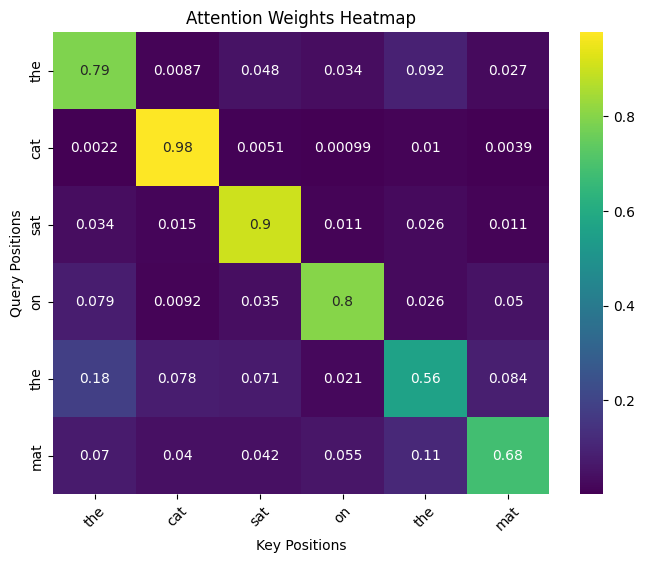

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import math

sentence = "the cat sat on the mat"
tokens = sentence.split()  # simple whitespace tokenizer
seq_len = len(tokens)

# Create dummy embeddings
d_model = 16
embeddings = torch.randn(1, 1, seq_len, d_model)  

# Treat embeddings as Q, K, V
Q = embeddings
K = embeddings
V = embeddings

# Compute Scaled Dot-Product Attention
attention_weights = scaled_dot_product_attention(Q, K, V)[1]  # get attention weights

# Plot attention heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(attention_weights[0, 0].cpu().numpy(), annot=True, cmap="viridis", xticklabels=tokens, yticklabels=tokens)  
plt.title("Attention Weights Heatmap")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.xticks(rotation=45)

plt.show()



### **Task 2.3 Experiments (15 points)** 

**Experiment 1 — Change One Word:**

1. Use a simple sentence, for example:
    the cat sat on the mat
2. Compute and plot the attention weights as a heatmap.
3. Change one word in the sentence, for example:
    the dog sat on the mat
4. Recompute and plot the attention heatmap.
5. Compare the two heatmaps and explain whether the attention pattern changed.

**Experiment 2 — Compare Different Attention Heads:**

Repeat the attention visualization using at least two different attention heads.

For each head, create separate projection matrices:

$$W_Q, W_K, W_V$$

Use them to compute:
$$Q=XW_Q, K=XW_K, V=XW_V$$

Then compute and plot the attention weights for each head.

**Questions**

Answer briefly:

1. Did changing one word affect the attention weights? Why or why not?
2. Do different attention heads focus on different tokens?
3. Why might multi-head attention be useful in Transformer models?

#### Experiment 1 — Change One Word

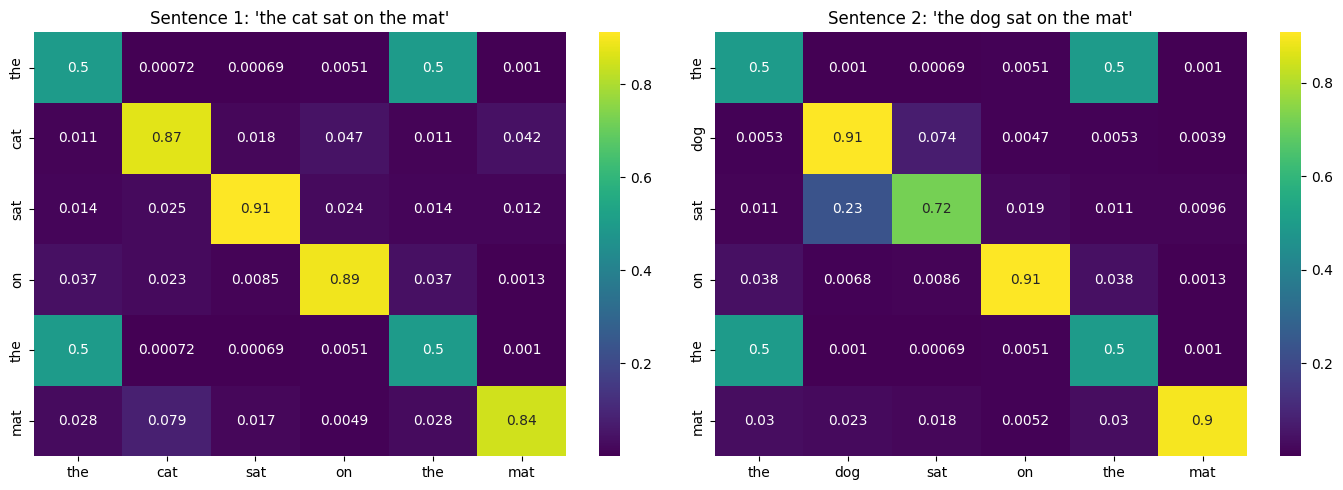

In [44]:
import torch.nn as nn

torch.manual_seed(42)  

# Scaled Dot-Product Attention function
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)  
    scores = Q.matmul(K.transpose(-2, -1)) / math.sqrt(d_k)  
    if mask is not None:  
        scores = scores.masked_fill(mask == 0, float("-inf"))  
    attn = torch.softmax(scores, dim=-1)  
    out = attn.matmul(V)  
    return out, attn 

# Function to plot attention heatmaps for two sets of attention weights
def plot_attn_comparison(attn1, attn2, tokens1, tokens2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  
    sns.heatmap(attn1[0, 0].cpu().detach().numpy(), annot=True, cmap="viridis", 
                xticklabels=tokens1, yticklabels=tokens1, ax=axes[0])  
    axes[0].set_title(title1)  
    
    sns.heatmap(attn2[0, 0].cpu().detach().numpy(), annot=True, cmap="viridis", 
                xticklabels=tokens2, yticklabels=tokens2, ax=axes[1])  
    axes[1].set_title(title2)  
    plt.tight_layout()  
    plt.show()  

#Experiment 1: Compare attention patterns for two similar sentences

d_model = 16  
vocab = ["the", "cat", "dog", "sat", "on", "mat"]  
embedding_lookup = {word: torch.randn(d_model) for word in vocab}  

def sentence_to_tensor(sentence):
    tokens = sentence.split()  
    
    return torch.stack([embedding_lookup[w] for w in tokens]).unsqueeze(0), tokens  

X1, tokens1 = sentence_to_tensor("the cat sat on the mat")  
X2, tokens2 = sentence_to_tensor("the dog sat on the mat")  

Q1 = K1 = V1 = X1.unsqueeze(1)  
Q2 = K2 = V2 = X2.unsqueeze(1)  

_, attn1 = scaled_dot_product_attention(Q1, K1, V1)  
_, attn2 = scaled_dot_product_attention(Q2, K2, V2)  


plot_attn_comparison(attn1, attn2, tokens1, tokens2, 
                     "Sentence 1: 'the cat sat on the mat'", 
                     "Sentence 2: 'the dog sat on the mat'")  



#### Experiment 2 — Compare Different Attention Heads

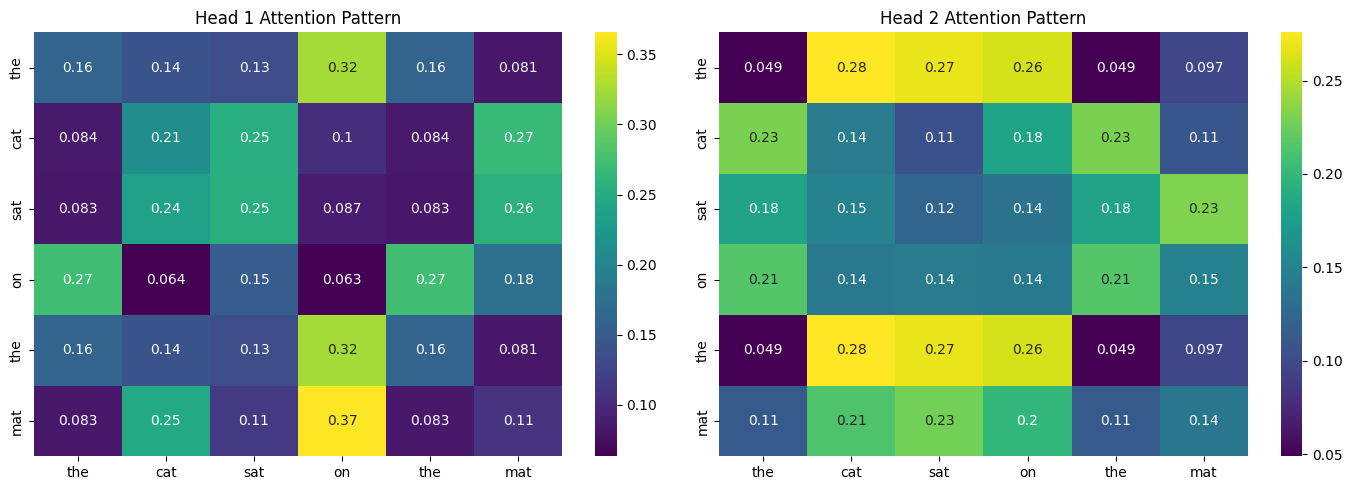

In [45]:
d_k = 8  

W_Q1 = nn.Linear(d_model, d_k, bias=False)  
W_K1 = nn.Linear(d_model, d_k, bias=False)  
W_V1 = nn.Linear(d_model, d_k, bias=False)  

W_Q2 = nn.Linear(d_model, d_k, bias=False)  
W_K2 = nn.Linear(d_model, d_k, bias=False)  
W_V2 = nn.Linear(d_model, d_k, bias=False)  

def get_head_attention(X, W_Q, W_K, W_V):
    Q = W_Q(X).unsqueeze(1)  
    K = W_K(X).unsqueeze(1)  
    V = W_V(X).unsqueeze(1)  
    _, attn = scaled_dot_product_attention(Q, K, V)  
    return attn  

attn_head1 = get_head_attention(X1, W_Q1, W_K1, W_V1)  
attn_head2 = get_head_attention(X1, W_Q2, W_K2, W_V2)  

plot_attn_comparison(attn_head1, attn_head2, tokens1, tokens1, 
                     "Head 1 Attention Pattern", 
                     "Head 2 Attention Pattern")  

#### Answer Questions:

1. Yes, it did effect attention wieghts but only in specific regions. 
- What changed: The attention weights in the row and column corresponding to the swapped token ("cat" -> "dog") changed significantly. Because the new word has a completely different, uncorrelated vector representation, its dot products with all other tokens changed, altering the resulting softmax probabilities.
- What stayed the same: The attention weights between all other unchanged words remained identical. Because raw embeddings were used directly without contextual layers, swapping one token has no mathematical effect on the isolated dot products of the remaining stable vectors.

2. Yes they focus on different tokens. Because each attention head utilizes its own distinct, randomly initialized projection matrices (W_Q, W_K, W_V), they map the identical input sequence into completely separate, uncorrelated vector subspaces. This geometric divergence causes the calculated dot-product similarities and the final attention distributions to look entirely different betweeen different heads.
   
3. Multi-head attention allows a model to simultaneously attend to information from different representation subspaces at different positions. Instead of averaging all word relationships into a single blurry pattern, a trained model leverages these distinct heads to specialize in parallel. For example, one head can focus on tracking grammatical dependencies (connecting a verb to its subject), while another head simultaneously focuses on local modifier-noun relationships or broader contextual framing.

<!--  -->